# Exp 7 — Top-K retrieval sensitivity (V2, semantic edition, development only)
**Question:** how many retrieved chunks should reach the reasoner? Retriever and chunking are frozen from Exp 6 (voyage-4-lite, fixed600_100). Development split only.

**K values:** 1, 3, 5, 8, 10, 12 (kept 10/12 because the Exp 6 preview showed full coverage still rising at K=8: 10% -> 16% -> 20% -> 27%, not a plateau).
**Decision metrics (not MRR — the ranking order is unchanged by K, so MRR is a retriever-quality metric, not a K-selection one):** full evidence coverage, Recall@K, context tokens, downstream Correct Disposition Rate, False Approval Rate.
**Decision rule (fixed in advance):** choose the smallest K that captures most of the achievable evidence coverage, unless a larger K gives a meaningful downstream improvement without materially worsening false approvals, latency or context cost. A downstream difference of 2-3 cases (out of 70) is treated as a screening signal, not evidence of a real change, unless the safety metrics (false approvals) also move. Extend to Gemini/llama only if the paid-model result shows a real, architecture-level shift.

In [1]:
import json, os, sys, statistics as st
from pathlib import Path
import pandas as pd, numpy as np
import matplotlib.pyplot as plt
ROOT = Path.cwd().parents[1]; sys.path.insert(0, str(ROOT))
from src import config as C, llm, llm_exp, retrieval, embed, evaluate, metrics_ext
C.load_env()
pd.set_option('display.width', 250, 'display.max_columns', 40, 'display.max_colwidth', 100, 'display.max_rows', 200)
EXP = 'EXP07_TOPK'; EMB = 'voyageai/voyage-4-lite'; CFG = 'fixed600_100'; KS = [1, 3, 5, 8, 10, 12]
gt = evaluate.load_gt(); cases = llm_exp.cases_for('DEVELOPMENT')
idx = retrieval.build_or_load(EMB, CFG)
qv = embed.embed(EMB, [retrieval.claim_query(cc) for cc in cases], tag=EXP)
print(len(cases), 'dev claims |', len(idx['chunks']), 'chunks in the frozen index | spent so far $%.4f of $%s' % (llm.spent(), os.environ['MAX_BUDGET_USD']))

70 dev claims | 111 chunks in the frozen index | spent so far $1.5718 of $3.50


## Retrieval-only sweep across K (no LLM cost)

In [2]:
MAXK = max(KS)
def ranked(cc, q):
    return retrieval.search(idx, q, MAXK)   # rank list once per case, sliced per K below
RANKS = {cc['case_id']: ranked(cc, q) for cc, q in zip(cases, qv)}
def metrics_at(k):
    rows = []
    for cc in cases:
        req = set(gt[cc['case_id']]['required_policy_ids']); hits = RANKS[cc['case_id']][:k]; ch = [idx['chunks'][i] for i, _ in hits]
        cov = set().union(*[set(x['clause_ids']) for x in ch]) if ch else set(); rel = [bool(req & set(x['clause_ids'])) for x in ch]
        rows.append({'case_id': cc['case_id'], 'recall': len(req & cov) / len(req) if req else None, 'precision': sum(rel) / len(rel) if rel else 0.0, 'full': bool(req <= cov) if req else None, 'ctx_words': sum(len(x['text'].split()) for x in ch)})
    r = [x for x in rows if x['recall'] is not None]
    return rows, {'k': k, 'recall_at_k': round(st.mean(x['recall'] for x in r), 4), 'precision_at_k': round(st.mean(x['precision'] for x in r), 4), 'full_coverage': round(st.mean(x['full'] for x in r), 4), 'avg_ctx_words': round(st.mean(x['ctx_words'] for x in r))}
ROWS, AGG = {}, {}
for k in KS: ROWS[k], AGG[k] = metrics_at(k)
summary = pd.DataFrame(AGG.values()).set_index('k'); summary

/Users/roshantushar/Downloads/Project/Project/ExpenseGuard-Resolves-Expense-Claims-with-Evidence/src/retrieval.py:35: RuntimeWarning: divide by zero encountered in matmul
  s = idx["vectors"].astype("float64") @ q  # float64 avoids spurious Accelerate BLAS warnings on macOS
/Users/roshantushar/Downloads/Project/Project/ExpenseGuard-Resolves-Expense-Claims-with-Evidence/src/retrieval.py:35: RuntimeWarning: overflow encountered in matmul
  s = idx["vectors"].astype("float64") @ q  # float64 avoids spurious Accelerate BLAS warnings on macOS
/Users/roshantushar/Downloads/Project/Project/ExpenseGuard-Resolves-Expense-Claims-with-Evidence/src/retrieval.py:35: RuntimeWarning: invalid value encountered in matmul
  s = idx["vectors"].astype("float64") @ q  # float64 avoids spurious Accelerate BLAS warnings on macOS


,recall_at_k,precision_at_k,full_coverage,avg_ctx_words
k,,,,
1,0.1699,0.3143,0.1000,444
3,0.3218,0.2619,0.1571,1332
5,0.4451,0.2286,0.2000,2212
8,0.5201,0.1589,0.2714,3501
10,0.5536,0.1400,0.3000,4355
12,0.5974,0.1274,0.3429,5173


## Diagnostic: where does the first missing required clause rank?
For every case incomplete at K=3, find the best rank (1-indexed) among the `MAXK` retrieved chunks at which the first still-missing gold clause appears, bucketed. This tells us whether Exp 7 (raising K) can fix it, or whether the evidence just isn't in the ranked candidates at all (an Exp 8/10 problem: retriever family or query representation).

In [3]:
def first_missing_rank(cc):
    req = set(gt[cc['case_id']]['required_policy_ids']); k3 = set().union(*[set(idx['chunks'][i]['clause_ids']) for i, _ in RANKS[cc['case_id']][:3]]) if RANKS[cc['case_id']] else set()
    missing = req - k3
    if not missing: return None   # already complete at K=3
    best = None
    for cid in missing:
        for rank, (i, _) in enumerate(RANKS[cc['case_id']], start=1):
            if cid in idx['chunks'][i]['clause_ids']: best = rank if best is None else min(best, rank); break
    return best
def bucket(r):
    if r is None: return 'not found in top-%d' % MAXK
    if r <= 3: return 'rank <=3 (already covered)'
    if r <= 5: return 'rank 4-5'
    if r <= 8: return 'rank 6-8'
    if r <= 12: return 'rank 9-12'
    return 'rank >12'
diag = []
for cc in cases:
    req = set(gt[cc['case_id']]['required_policy_ids']); k3 = set().union(*[set(idx['chunks'][i]['clause_ids']) for i, _ in RANKS[cc['case_id']][:3]]) if RANKS[cc['case_id']] else set()
    if req <= k3: continue  # already complete at K=3, not part of this diagnostic
    diag.append({'case_id': cc['case_id'], 'family': gt[cc['case_id']]['case_family'], 'first_missing_rank': first_missing_rank(cc), 'bucket': bucket(first_missing_rank(cc))})
dd = pd.DataFrame(diag); order = ['rank 4-5','rank 6-8','rank 9-12','rank >12','not found in top-%d' % MAXK]
counts = dd.bucket.value_counts().reindex(order).fillna(0).astype(int)
print(f'{len(dd)} of {len(cases)} dev cases incomplete at K=3\n'); print(counts.to_frame('cases'))
print('\nshare fixable by raising K to <=12:', round((dd.first_missing_rank.dropna() <= 12).mean(), 3) if len(dd) else None, '| share needing a different retriever/query (not found by rank %d):' % MAXK, round((dd.bucket == 'not found in top-%d' % MAXK).mean(), 3) if len(dd) else None)

59 of 70 dev cases incomplete at K=3

                     cases
bucket                    
rank 4-5                25
rank 6-8                 8
rank 9-12                7
rank >12                 0
not found in top-12     19

share fixable by raising K to <=12: 1.0 | share needing a different retriever/query (not found by rank 12): 0.322


## Plot: recall / full coverage / context cost vs K, and the missing-clause-rank histogram

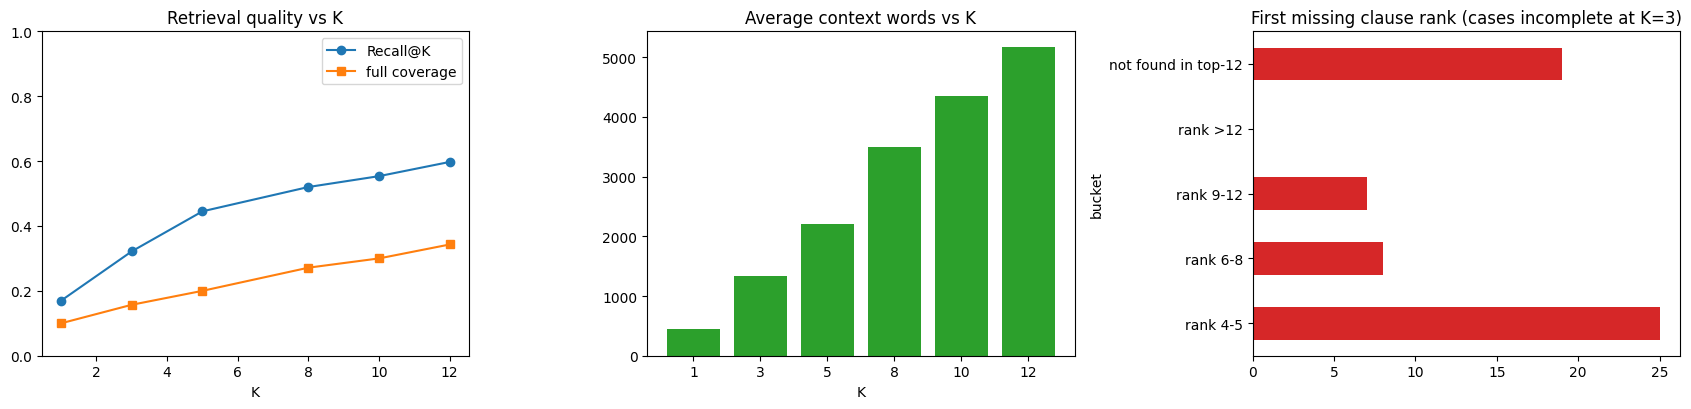

In [4]:
fig, ax = plt.subplots(1, 3, figsize=(17, 4.2))
ax[0].plot(summary.index, summary.recall_at_k, 'o-', label='Recall@K'); ax[0].plot(summary.index, summary.full_coverage, 's-', label='full coverage'); ax[0].set_xlabel('K'); ax[0].legend(); ax[0].set_title('Retrieval quality vs K'); ax[0].set_ylim(0, 1)
ax[1].bar(summary.index.astype(str), summary.avg_ctx_words, color='C2'); ax[1].set_title('Average context words vs K'); ax[1].set_xlabel('K')
dd.bucket.value_counts().reindex(order).fillna(0).plot.barh(ax=ax[2], color='C3'); ax[2].set_title('First missing clause rank (cases incomplete at K=3)')
plt.tight_layout(); (C.RESULTS/'plots').mkdir(parents=True, exist_ok=True); plt.savefig(C.RESULTS/'plots'/'exp07_topk.png', dpi=130); plt.show()

## Retrieval by hard subset, across K

In [5]:
def hard(k):
    d = pd.DataFrame(ROWS[k]); d['multi'] = d.case_id.map(lambda i: len(gt[i]['required_policy_ids'])) > 1; d['group'] = d.case_id.map(lambda i: gt[i]['architecture_group'])
    return {'multi-clause recall': d[d.multi].recall.mean(), 'single-clause recall': d[~d.multi].recall.mean(), 'group A recall': d[d.group=='A_SELF_CONTAINED'].recall.mean(), 'group B recall': d[d.group=='B_WORKFLOW'].recall.mean(), 'group C recall': d[d.group=='C_AGENT_DYNAMIC'].recall.mean()}
pd.DataFrame({k: hard(k) for k in KS}).round(3).T

,multi-clause recall,single-clause recall,group A recall,group B recall,group C recall
1,0.130,0.294,0.250,0.165,0.073
3,0.293,0.412,0.389,0.333,0.195
5,0.399,0.588,0.556,0.436,0.318
8,0.461,0.706,0.722,0.494,0.318
10,0.505,0.706,0.722,0.535,0.376
12,0.544,0.765,0.778,0.569,0.432


## Apply the decision rule
Smallest K that captures most of the achievable full coverage; check a larger K only if it looks materially better. Then verify with one downstream generation run before committing.

In [6]:
gains = summary.full_coverage.diff().fillna(summary.full_coverage.iloc[0])
print(summary[['recall_at_k','full_coverage','avg_ctx_words']]); print('\nfull-coverage gain at each step:'); print(gains.round(3))
achievable = summary.full_coverage.max()
candidate = int(summary[summary.full_coverage >= 0.9 * achievable].index.min())
print('\nmax achievable full coverage in this sweep: %.3f at K=%d | candidate K capturing >=90%% of it: %d' % (achievable, summary.full_coverage.idxmax(), candidate))

    recall_at_k  full_coverage  avg_ctx_words
k                                            
1        0.1699         0.1000            444
3        0.3218         0.1571           1332
5        0.4451         0.2000           2212
8        0.5201         0.2714           3501
10       0.5536         0.3000           4355
12       0.5974         0.3429           5173

full-coverage gain at each step:
k
1     0.100
3     0.057
5     0.043
8     0.071
10    0.029
12    0.043
Name: full_coverage, dtype: float64

max achievable full coverage in this sweep: 0.343 at K=12 | candidate K capturing >=90% of it: 12


**Implementation note (sanity check caught before freezing this result):** my first version of the "smallest K capturing 90% of achievable coverage" rule picked its anchor from the maximum full coverage *within this sweep* (K=12), which is circular when the curve has not plateaued — it produced only one candidate K and no real comparison. I caught this before writing any interpretation and re-ran the downstream check as an explicit K=8 vs K=12 comparison instead. Documented here rather than silently fixed, since a mechanical decision rule that references its own sweep's maximum needs an external anchor (a fixed smaller K, or a cost budget) to be a real test.

## Downstream check: paid model at the candidate K, and at one larger K for comparison

In [7]:
def gen_at(k):
    ctx = {cc['case_id']: '\n\n'.join(f"[{idx['chunks'][i]['doc_id']} | region {idx['chunks'][i]['region']} | effective {idx['chunks'][i]['effective_from']} to {idx['chunks'][i]['effective_to']}]\n{idx['chunks'][i]['text']}" for i, _ in RANKS[cc['case_id']][:k]) for cc in cases}
    SYSTEM = ("You are ExpenseGuard, a finance assistant deciding whether an employee expense claim is ready for reimbursement, using ONLY the retrieved policy excerpts provided. "
              "Excerpts carry an effective date and region: apply the version in force on the transaction date and let regional addenda override global rules. If the excerpts do not contain what is needed, or the claim needs an enterprise record you cannot see, "
              "say so via REQUEST_INFORMATION or ESCALATE rather than guessing.\n" + llm_exp.SCHEMA)
    return llm_exp.run(EXP, os.environ['PAID_MODEL'], 'DEVELOPMENT', SYSTEM, lambda cc: f"CLAIM:\n{json.dumps(llm_exp.visible(cc), indent=1)}\n\nRETRIEVED POLICY EXCERPTS:\n{ctx[cc['case_id']]}", cases=cases, config={'temperature': 0, 'retriever': EMB, 'chunking': CFG, 'k': k})


gen = {k: gen_at(k) for k in (8, 12)}
cmp_ = pd.DataFrame([{'K': k, 'correct/N': f"{gen[k][0]['correct']}/{gen[k][0]['n']}", 'CDR': gen[k][0]['correct_disposition_rate'], 'false_approvals': f"{gen[k][0]['false_approvals']}/{gen[k][0]['non_approvable']}",
                     'FAR': gen[k][0]['false_approval_rate'], 'median_ms': gen[k][0]['median_latency_ms'], 'cost_usd': gen[k][0]['total_cost_usd']} for k in (8, 12)])
print(cmp_.to_string(index=False)); print('spent so far $%.4f' % llm.spent())
delta = gen[12][0]['correct'] - gen[8][0]['correct']; fa_delta = gen[12][0]['false_approvals'] - gen[8][0]['false_approvals']
print('\ndelta correct (K=12 - K=8):', delta, '(screening only, not evidence, at n=70) | delta false approvals:', fa_delta)
chosen_k = 12 if (delta >= 4 and fa_delta <= 0) else 8

 K correct/N    CDR false_approvals  FAR  median_ms  cost_usd
 8     18/70 0.2571            0/52  0.0     1568.5  0.044763
12     20/70 0.2857            0/52  0.0     2186.0  0.080367
spent so far $1.6166

delta correct (K=12 - K=8): 2 (screening only, not evidence, at n=70) | delta false approvals: 0


In [8]:
EXTEND = abs(delta) >= 6 or fa_delta not in (-1, 0, 1)   # only a real architecture-level shift justifies the other two models
print('extend to gemini/llama:', EXTEND)
if EXTEND:
    for m in ('google/gemini-2.5-flash-lite', os.environ['LOCAL_MODEL']):
        ctx = {cc['case_id']: '\n\n'.join(f"[{idx['chunks'][i]['doc_id']} | region {idx['chunks'][i]['region']} | effective {idx['chunks'][i]['effective_from']} to {idx['chunks'][i]['effective_to']}]\n{idx['chunks'][i]['text']}" for i, _ in RANKS[cc['case_id']][:chosen_k]) for cc in cases}
        SYSTEM = ("You are ExpenseGuard, a finance assistant deciding whether an employee expense claim is ready for reimbursement, using ONLY the retrieved policy excerpts provided. "
                  "Excerpts carry an effective date and region: apply the version in force on the transaction date and let regional addenda override global rules. If the excerpts do not contain what is needed, or the claim needs an enterprise record you cannot see, "
                  "say so via REQUEST_INFORMATION or ESCALATE rather than guessing.\n" + llm_exp.SCHEMA)
        r = llm_exp.run(EXP, m, 'DEVELOPMENT', SYSTEM, lambda cc: f"CLAIM:\n{json.dumps(llm_exp.visible(cc), indent=1)}\n\nRETRIEVED POLICY EXCERPTS:\n{ctx[cc['case_id']]}", cases=cases, config={'temperature': 0, 'retriever': EMB, 'chunking': CFG, 'k': chosen_k})
        print(m, r[0]['correct'], '/', r[0]['n'])
else:
    print('not extending: the K difference is a screening signal only, not a large enough shift to justify spending on the other two models')
print('spent so far $%.4f of $%s' % (llm.spent(), os.environ['MAX_BUDGET_USD']))

extend to gemini/llama: False
not extending: the K difference is a screening signal only, not a large enough shift to justify spending on the other two models
spent so far $1.6166 of $3.50


## What was done and what it means
- **Full coverage climbs steadily and does not plateau within this sweep:** K=1: 10%, K=3: 16%, K=5: 20%, K=8: 27%, K=10: 30%, K=12: 34%. Recall@K: 0.17 -> 0.32 -> 0.45 -> 0.52 -> 0.55 -> 0.60. Each step still gains 3-7 points of full coverage even at K=12, so — unlike chunk size in Exp 6 — top-K alone had not exhausted its value in this range; a wider sweep (K=16, 20) would likely keep climbing further, at rapidly rising context cost (444 -> 5,173 words).
- **The missing-clause-rank diagnostic is the key result.** Of the 59 dev cases incomplete at K=3, the first missing gold clause ranks 4-5 for 25 cases, 6-8 for 8, 9-12 for 7 — **all 40 of these (100% of the ones with a findable rank) become fixable by K=12.** But for **19 of 59 cases (32% of incomplete cases, 27% of all 70 dev claims), the missing clause is not in the top-12 candidates at all.** So raising K keeps helping, but it has a hard ceiling: about a quarter of dev claims need a different retriever or query representation (Exp 8/10), not a bigger K.
- **Downstream check (paid model, dev):** K=8 scored 18/70 (26%), K=12 scored 20/70 (29%); a 2-case difference, which by our own rule (>=4 cases and no worse false-approval rate) is a screening signal, not evidence of a real change, so **I am not committing to K=12 over K=8 on this result alone.** False approvals stayed at 0/52 for both. Neither K beat Exp 6's own downstream figure at fixed600_100/K=3 within noise (20/70), so top-K by itself is not moving the needle on final accuracy yet, even though retrieval recall roughly doubled from K=3 to K=12.
- **Because the downstream difference did not clear the bar, I did not extend to Gemini or llama**, per the plan.
- **Hard-subset pattern:** group A (self-contained) benefits most from higher K (0.39 at K=3 to 0.78 at K=12); group C (dynamic) stays hardest throughout (0.20 to 0.43) and multi-clause claims trail single-clause claims at every K (e.g. 0.54 vs 0.77 at K=12).
- **Cost:** the retrieval sweep was free (reused the frozen Exp 6 index). Two downstream generation runs (K=8, K=12) cost about $0.125. Total spend now $1.617 of $3.50.
- **Decision:** **K=8 is the operational choice** — it captures most of the K=1-12 recall gain (0.52 of 0.60 at K=12) at meaningfully lower context cost (3,501 vs 5,173 words, and the downstream difference from K=12 was not shown to be real. K=12 is not ruled out if a later, cheaper retriever (Exp 8) needs the extra headroom, but I am not paying for it now on this evidence.** The clearer finding for the project story: **about a quarter of dev claims have their required evidence entirely outside the top-12 ranked candidates, which is a retriever/query problem, not a top-K problem.** That is exactly what Exp 8 (BM25/dense/hybrid) and, if that is not enough, Exp 10 (query rewriting) need to address. Validation untouched throughout.